In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
sns.set()

In [2]:
df_train = pd.read_csv("../../data/dtec/dTEC_train.csv", index_col=0)
df_test = pd.read_csv("../../data/dtec/dTEC_test.csv", index_col=0)

In [3]:
df_train.head()

,Time,SatID,dTEC,Class,Event_name,StationID,dTEC-10,dTEC-9,dTEC-8,dTEC-7,dTEC-6,dTEC-5,dTEC-4,dTEC-3,dTEC-2,dTEC-1
0,3/11/2011 5:05,G15,-0.055487,0,Tohoku,J0041,-0.000381,0.003298,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487
1,3/11/2011 5:06,G15,0.028164,0,Tohoku,J0041,0.003298,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164
2,3/11/2011 5:06,G15,0.078863,0,Tohoku,J0041,0.004521,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863
3,3/11/2011 5:07,G15,0.011011,0,Tohoku,J0041,-0.023128,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863,0.011011
4,3/11/2011 5:07,G15,-0.067521,0,Tohoku,J0041,0.003902,0.039302,0.006738,-0.011430,-0.038867,-0.055487,0.028164,0.078863,0.011011,-0.067521


In [4]:
df_test.head()

,Time,SatID,dTEC,Class,Event_name,StationID,dTEC-10,dTEC-9,dTEC-8,dTEC-7,dTEC-6,dTEC-5,dTEC-4,dTEC-3,dTEC-2,dTEC-1
0,1/15/2022 3:05,G10,-0.059215,0,Tonga,LAUT,0.074218,0.041935,0.009234,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215
1,1/15/2022 3:05,G10,-0.059376,0,Tonga,LAUT,0.041935,0.009234,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376
2,1/15/2022 3:06,G10,-0.061546,0,Tonga,LAUT,0.009234,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376,-0.061546
3,1/15/2022 3:06,G10,-0.069589,0,Tonga,LAUT,-0.020017,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376,-0.061546,-0.069589
4,1/15/2022 3:07,G10,-0.083846,0,Tonga,LAUT,-0.041198,-0.052470,-0.056392,-0.057517,-0.058520,-0.059215,-0.059376,-0.061546,-0.069589,-0.083846


In [5]:
alaska = df_train[df_train['Event_name'] == 'Alaska_18']
alaska_class = alaska['Class']
alaska = alaska.drop(['SatID', 'Class', 'StationID', 'Event_name', 'dTEC'], axis=1)
alaska['Time'] = pd.to_datetime(alaska['Time'])
alaska = alaska.set_index('Time')
alaska.head()

,dTEC-10,dTEC-9,dTEC-8,dTEC-7,dTEC-6,dTEC-5,dTEC-4,dTEC-3,dTEC-2,dTEC-1
Time,,,,,,,,,,
2018-01-23 09:17:00,-0.000306,-0.000296,-0.018545,-0.021405,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716
2018-01-23 09:17:00,-0.000296,-0.018545,-0.021405,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716,-0.003521
2018-01-23 09:18:00,-0.018545,-0.021405,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716,-0.003521,0.015844
2018-01-23 09:18:00,-0.021405,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716,-0.003521,0.015844,0.011721
2018-01-23 09:18:00,0.004732,0.023314,0.018649,0.003173,-0.017687,-0.024716,-0.003521,0.015844,0.011721,-0.000781


In [6]:
alaska_vals = alaska.values

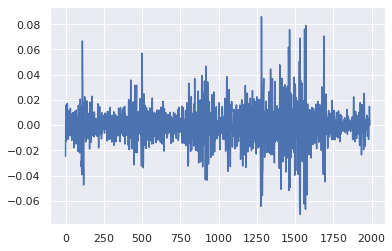

In [7]:
plt.plot(alaska['dTEC-1'].values)

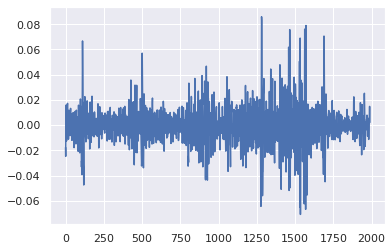

In [8]:
plt.plot(alaska['dTEC-2'].values)

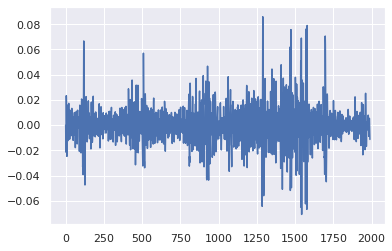

In [9]:
plt.plot(alaska['dTEC-10'].values)

<AxesSubplot:ylabel='Count'>

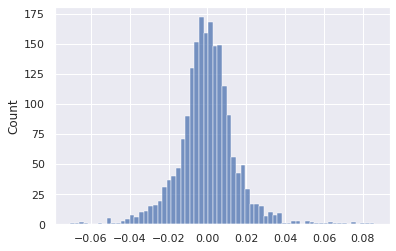

In [10]:
sns.histplot(alaska_vals[:, 0])

<AxesSubplot:ylabel='Count'>

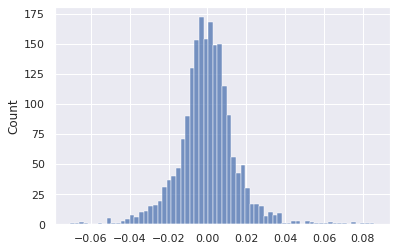

In [11]:
sns.histplot(alaska_vals[:, 1])

In [12]:
scaler = StandardScaler()
alaska_vals = scaler.fit_transform(alaska_vals)

In [13]:
np.savetxt('../../data/dtec/alaska.csv', alaska_vals, delimiter=",")

In [14]:
np.linalg.det(np.cov(alaska_vals.T))

5.5933257298144554e-08

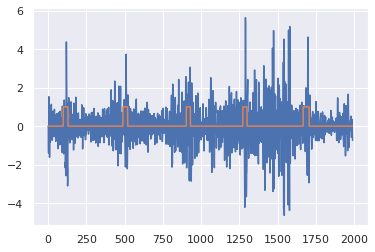

In [19]:
plt.plot(alaska_vals[:, 0])
plt.plot(alaska_class.values)

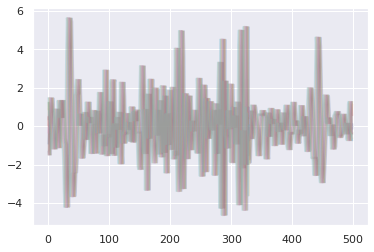

In [29]:
plt.plot(alaska_vals[1250:1750, :], alpha=0.25)

<AxesSubplot:>

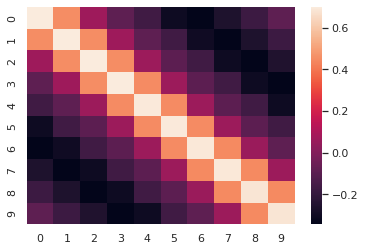

In [23]:
sns.heatmap(np.cov(alaska_vals[0:1000, :].T))

<AxesSubplot:>

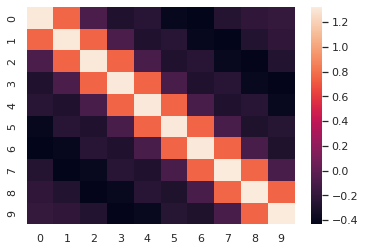

In [24]:
sns.heatmap(np.cov(alaska_vals[1000::, :].T))

In [25]:
first_cov = np.cov(alaska_vals[0:1000, :].T)
second_cov = np.cov(alaska_vals[1000::, :].T)
first_diag = np.diag(first_cov)
second_diag = np.diag(second_cov)
first_diag

array([0.69898444, 0.69898614, 0.69579251, 0.69499164, 0.69432963,
       0.69351676, 0.69068076, 0.6874436 , 0.68212439, 0.68154676])

In [26]:
second_diag

array([1.30603752, 1.30605709, 1.30928932, 1.31010981, 1.31078328,
       1.31159851, 1.31443757, 1.31766801, 1.32304613, 1.32366514])

<AxesSubplot:>

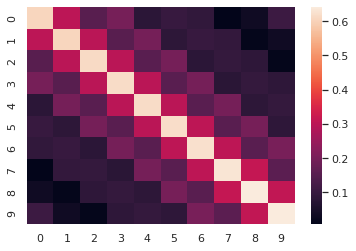

In [31]:
sns.heatmap(np.abs(second_cov-first_cov))

In [72]:
alaska_vals.shape

(1990, 10)

In [73]:
1530+50

1580

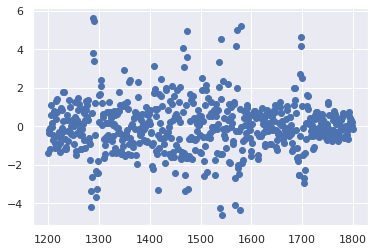

In [90]:
plt.scatter(x=np.arange(1200, 1800), y=alaska_vals[1200:1800, 0])

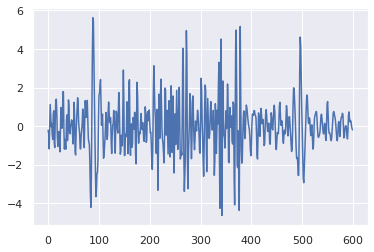

In [78]:
plt.plot(alaska_vals[1200:1800, 1])

In [ ]:
plt.plot()